# 06 — Channel mapping

Attach MM / AM / HF channel to each transaction via Salesperson ID → channel key. Replaces the unreliable Customer Type field.

**Upstream:** sales_tagged.parquet, slprsn_key.parquet

**Output:** sales_tagged_channel.parquet

**Promotes to:** `src/channel.py` once verified.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
ART.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


## 2. Load upstream

In [2]:
sales = pd.read_parquet(ART / 'sales_tagged.parquet')
slprsn_key = pd.read_parquet(ART / 'slprsn_key.parquet')

print(f'sales       : {sales.shape}')
print(f'slprsn_key  : {slprsn_key.shape}  cols={list(slprsn_key.columns)}')
print('\nSALESCHANNEL mix in key:')
print(slprsn_key['SALESCHANNEL'].value_counts().to_string())


sales       : (236818, 44)
slprsn_key  : (46, 3)  cols=['SLPRSNID', 'SALESCHANNEL', 'SALESCHANNEL_DESC']

SALESCHANNEL mix in key:
SALESCHANNEL
MM    30
AM    14
HF     2


## 3. Do the work

In [3]:
# Attach SALESCHANNEL / SALESCHANNEL_DESC to each sales row via SLPRSNID.
# The Customer Type field in sales is unreliable (free-text, inconsistent);
# SLPRSNID -> channel is the source of truth POP shared in the key file.
#
# Step 05 now attaches channel upstream so its per-channel markdown detector
# can run, so by the time we land here the columns are usually already present.
# Keep this cell idempotent: if channel is already attached, skip the merge.

from src.channel import attach_channel

if 'SALESCHANNEL' in sales.columns:
    print('SALESCHANNEL already attached upstream (step 05) — skipping merge.')
else:
    sales = attach_channel(sales, slprsn_key)
    print('channel attached inline.')

# ---- Summary ---------------------------------------------------------------
n = len(sales)
cov = sales['SALESCHANNEL'].notna().mean() * 100
print(f'total rows           : {n:,}')
print(f'channel coverage     : {cov:.2f}%  (rows with SALESCHANNEL assigned)')
print(f'unmatched SLPRSNID   : {sales["SALESCHANNEL"].isna().sum()}')
print()
print('rows per channel:')
print(sales['SALESCHANNEL'].value_counts(dropna=False).to_string())
print()
print('rows per channel (with description):')
print(sales.groupby(['SALESCHANNEL', 'SALESCHANNEL_DESC'], dropna=False).size()
           .sort_values(ascending=False).to_string())


SALESCHANNEL already attached upstream (step 05) — skipping merge.
total rows           : 236,818
channel coverage     : 100.00%  (rows with SALESCHANNEL assigned)
unmatched SLPRSNID   : 4

rows per channel:
SALESCHANNEL
MM     113226
AM     107399
HF      16189
NaN         4

rows per channel (with description):
SALESCHANNEL  SALESCHANNEL_DESC         
MM            American Mainstream Market    113226
AM            Asian Ethnic Market           107399
HF            Health Food                    16189
NaN           NaN                                4


## 4. Validate

row count preserved: 236,818
null SLPRSNID rows   : 4
null SALESCHANNEL    : 4  (should equal null SLPRSNID)

channel × DC row counts:
DC               LA     NJ     SF   NaN
SALESCHANNEL                           
AM            27332  37501  41479  1087
HF             2210   9795   4160    24
MM            22309  63768  26081  1068
NaN               0      4      0     0

channel × brand (top brands only):
brand         am gsg  ferrero  ginger chew  kjeldsens  kwan loong  pop tea  tiger balm  totole
SALESCHANNEL                                                                                  
AM             23517    17750        25079       3870        3677    22104        6484    4350
HF                41        0         6608          0          39     4302        5199       0
MM              7426      621        35843        382         396     6728       61803       0

clean-demand share by channel:
              clean_rows  total_rows  clean_share
SALESCHANNEL                    

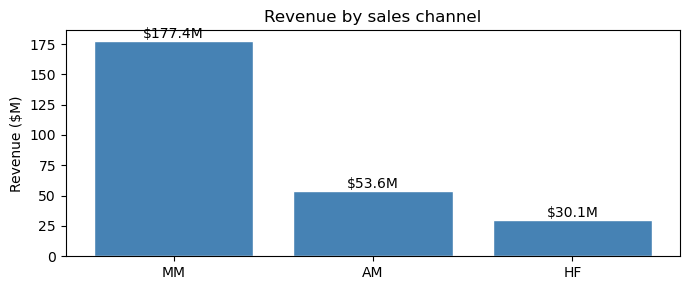

In [4]:
# ---- Check 1: row count preserved ------------------------------------------
sales_in = pd.read_parquet(ART / 'sales_tagged.parquet')
assert len(sales) == len(sales_in), f'Row count changed! {len(sales_in)} -> {len(sales)}'
print(f'row count preserved: {len(sales):,}')

# ---- Check 2: null SALESCHANNEL rows (should be <= null SLPRSNID) ---------
null_slprsn = sales['SLPRSNID'].isna().sum()
null_chan   = sales['SALESCHANNEL'].isna().sum()
print(f'null SLPRSNID rows   : {null_slprsn}')
print(f'null SALESCHANNEL    : {null_chan}  (should equal null SLPRSNID)')
assert null_chan == null_slprsn, 'Extra unmatched SLPRSNIDs — slprsn_key is incomplete.'

# ---- Check 3: channel × DC matrix -----------------------------------------
print('\nchannel × DC row counts:')
print(pd.crosstab(sales['SALESCHANNEL'], sales['DC'], dropna=False).to_string())

# ---- Check 4: channel × brand (do AM brands skew to Asian Ethnic?) --------
print('\nchannel × brand (top brands only):')
top_brands = sales['brand'].value_counts().head(8).index
print(pd.crosstab(
    sales.loc[sales['brand'].isin(top_brands), 'SALESCHANNEL'],
    sales.loc[sales['brand'].isin(top_brands), 'brand'],
).to_string())

# ---- Check 5: channel × clean-demand share --------------------------------
print('\nclean-demand share by channel:')
print(sales.groupby('SALESCHANNEL', dropna=False)['is_clean_demand']
           .agg(['sum', 'size', 'mean'])
           .rename(columns={'sum': 'clean_rows', 'size': 'total_rows', 'mean': 'clean_share'})
           .to_string())

# ---- Check 6: bar chart — revenue share by channel ------------------------
rev = (sales.dropna(subset=['SALESCHANNEL'])
            .groupby('SALESCHANNEL')['XTNDPRCE_adj']
            .sum().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(list(rev.index), rev.values / 1e6, color='steelblue', edgecolor='white')
ax.set_ylabel('Revenue ($M)')
ax.set_title('Revenue by sales channel')
for i, v in enumerate(rev.values):
    ax.text(i, v / 1e6, f'${v/1e6:.1f}M', ha='center', va='bottom')
plt.tight_layout()
plt.show()


## 5. Save downstream artifact

In [5]:
sales.to_parquet(ART / 'sales_tagged_channel.parquet')
print(f'sales_tagged_channel  {sales.shape}  -> sales_tagged_channel.parquet')
print(f'columns added: SALESCHANNEL, SALESCHANNEL_DESC')


sales_tagged_channel  (236818, 44)  -> sales_tagged_channel.parquet
columns added: SALESCHANNEL, SALESCHANNEL_DESC


## 6. Promote

Once validation above looks right, extract the core logic into `src/channel.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.